In [21]:
from scipy.special import erfc
import matplotlib.pyplot as plt
import numpy as np

## Photon Detector

We should start by defining a function for an ideal photon dectector.

We know that for a coherent state, the photon number follows a Poisson distribution where $P(n)=e^{-|\gamma|^2}\frac{|\gamma|^{2n}}{n!}$, so the mean photon number is therefore $\langle n \rangle = |\gamma|^2$, and the probability of detecting zero photons is $P(n=0)=e^{-|\gamma|^2}$, leading to the following function to calculate the probabilities of detecting either zero or one photons, by other words, having a click or not. A click means that at least one photon was detected $(n \geq 1)$ so $P_{\mathrm{click}}=1-P(n=0)$.

In [22]:
def click_probabilities(amplitude):
    mean_photons = np.abs(amplitude)**2

    P_no_click = np.exp(-mean_photons)

    P_click = 1 - P_no_click

    return P_no_click, P_click

## Feedback Control

The total measurement must be divided into M bins of length $dt = \frac{1}{M}$.
For the binary coherent states $|\alpha\rangle$ and $|-\alpha\rangle$, their overlap is

$$
\langle \alpha|-\alpha\rangle
=
e^{-2|\alpha|^2}
$$

The squared magnitude is

$$
|\langle \alpha|-\alpha\rangle|^2
=
e^{-4|\alpha|^2}
$$

At time $t$, only a fraction $1-t$ of the signal remains. Therefore, the code uses

$$
\text{remaining overlap}
=
e^{-4|\alpha|^2(1-t)}
$$

In [ ]:
def dolinar_control(alpha, t, dt, P_plus, P_minus):
    """
    Posterior-dependent Dolinar-inspired control.

    The control strength depends on both:
        - the remaining distinguishability of the signal
        - the current posterior probabilities
    """

    # Squared overlap associated with the remaining part of the signal
    remaining_overlap = np.exp(-4 * np.abs(alpha)**2 * (1 - t))

    # Posterior-dependent denominator
    denominator = np.sqrt(1-4 * P_plus * P_minus * remaining_overlap)

    # Numerical protection for division by zero
    denominator = max(denominator, 1e-12)

    # Continuous-time control amplitude
    u = np.abs(alpha) / denominator

    # Scale to one time bin
    return u * np.sqrt(dt)

## Dolinar Measurement Simulation

The crucial part of the code is now defining a function to simulate a measurement, where true_state = +1 represents the $|\alpha \rangle$ state and true_state = -1 represents the $|-\alpha \rangle$ state.

Before any measurements, we assume both states have equal probabilities of $\frac{1}{2}$.

After measurement, if the probability for $|\alpha \rangle$ is larger, the displacement tries to cancel it so the direction of $\beta$ should be negative and vice-versa. This process then repeats after each measurement. 

The detector does not know which state was actually sent.
Therefore, the code calculates what the detector amplitude would be under each hypothesis.

In [ ]:
def dolinar_receiver(true_state, alpha, M, store_history=False):
    # Initial probabilities
    P_plus = 0.5
    P_minus = 0.5

    # Time step
    dt = 1 / M

    # Signal amplitude in each time bin
    alpha_bin = alpha * np.sqrt(dt)

    # Store histories
    P_plus_history = []
    P_minus_history = []

    click_history = []
    displacement_history = []

    #Sweep over all time bins (repeats measurements M times)
    for k in range(M):
        # Current time
        t = k * dt

        # Calculate Dolinar control amplitude for displacement |β|
        control = dolinar_control(alpha, t, dt, P_plus, P_minus)

        # Choose displacement direction
        if P_plus >= P_minus:
            beta = -control

        else:
            beta = control

        # Detector amplitudes under hypotheses
        amplitude_plus = (alpha_bin + beta)
        amplitude_minus = (-alpha_bin + beta)

        # Measurement probabilities
        #P(no click∣+α) and P(click∣+α)
        P_no_plus, P_click_plus = (click_probabilities(amplitude_plus))
        #P(no click∣−α) and P(click∣−α)
        P_no_minus, P_click_minus = (click_probabilities(amplitude_minus))

        # Generate the actual measurement
        actual_amplitude = (true_state * alpha_bin+beta)

        P_no_actual, P_click_actual = (click_probabilities(actual_amplitude))
        click = (np.random.random() < P_click_actual)

        # Bayesian update
        if click:
            likelihood_plus = P_click_plus
            likelihood_minus = P_click_minus

        else:
            likelihood_plus = P_no_plus
            likelihood_minus = P_no_minus
        
        #P(r)=P(r∣+)P(+)+P(r∣−)P(−)#
        normalization = (likelihood_plus * P_plus + likelihood_minus * P_minus)

        if normalization > 1e-15:
            P_plus = ((likelihood_plus*P_plus)/normalization)
            P_minus = ((likelihood_minus*P_minus)/normalization)

        # Store history
        if store_history:
            P_plus_history.append(P_plus)
            P_minus_history.append(P_minus)
            click_history.append(click)
            displacement_history.append(beta)

    # Final decision
    if P_plus >= P_minus:
        decision = +1

    else:
        decision = -1

    history = {"P_plus": np.array(P_plus_history), "P_minus": np.array(P_minus_history), "clicks": np.array(click_history), "displacements": np.array(displacement_history)}

    return decision, history

## Error Probability

Now we should define a function to calculate error probability.


In [ ]:
def calculate_dolinar_error(alpha, M=500, n_trials=5000):
    """Loops over a number of trials adding up the number of errors and returning the error rate."""
    
    errors = 0

    # Test |+alpha>
    for _ in range(n_trials):

        decision, _ = dolinar_receiver(true_state=+1, alpha=alpha, M=M)

        if decision != +1:
            errors += 1

    # Test |-alpha>
    for _ in range(n_trials):

        decision, _ = dolinar_receiver(true_state=-1, alpha=alpha, M=M)

        if decision != -1:
            errors += 1

    return errors / (2 * n_trials)

Now we calculate the error rate for a range of alpha values and plot the results.

In [ ]:
alphas = np.linspace(0.1, 2.0, 25)

P_dolinar = []

for alpha in alphas:
    error = calculate_dolinar_error(alpha, M=500, n_trials=5000)
    P_dolinar.append(error)

P_dolinar = np.array(P_dolinar)

## Error Comparison
To compare the error for different approximations, we now plot the values for Homodyne, Kennedy, dolinar, and ideal Helstrom detections.

In [ ]:
# Homodyne
P_homodyne = 0.5 * erfc(np.sqrt(2) * alphas)

# Kennedy
P_kennedy = 0.5 * np.exp(-4 * alphas**2)

# Helstrom
P_helstrom = 0.5 * (1-np.sqrt(1-np.exp(-4 * alphas**2)))

For the homodyne, the erfc is the error function:

$$
\operatorname{erfc}(x)
=
\frac{2}{\sqrt{\pi}}
\int_x^\infty e^{-t^2}\,dt.
$$

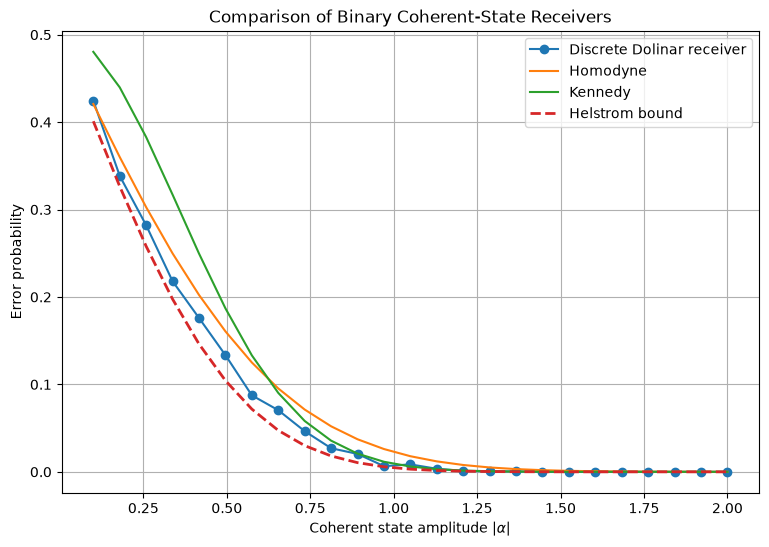

In [ ]:
plt.figure(figsize=(9, 6))

plt.plot(alphas, P_dolinar,"o-", label="Discrete Dolinar receiver")
plt.plot(alphas, P_homodyne, label="Homodyne")
plt.plot(alphas, P_kennedy, label="Kennedy")
plt.plot(alphas, P_helstrom, "--", linewidth=2, label="Helstrom bound")

plt.xlabel(r"Coherent state amplitude $|\alpha|$")
plt.ylabel(r"Error probability")
plt.title("Comparison of Binary Coherent-State Receivers")

plt.grid(True, which="both")
plt.legend()
plt.show()